In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yusufmurtaza01/tomato-leaf-disease")

print("Path to dataset files:", path)

100%|██████████| 445M/445M [00:03<00:00, 119MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2


In [2]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/labels
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/labels/val
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/labels/train
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/images
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/images/val
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/images/train


In [4]:
import yaml

yaml_path = "/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print(data)

{'path': '/kaggle/input/datasets/yusufmurtaza01/tomato-leaf-disease/tomato', 'train': 'images/train', 'val': 'images/val', 'test': '', 'nc': 10, 'names': ['Tomato__BacterialSpot', 'Tomato__EarlyBlight', 'Tomato__Healthy', 'Tomato__LateBlight', 'Tomato__LeafMold', 'Tomato__MosaicVirus', 'Tomato__SeptoriaLeafSpot', 'Tomato__SpiderMites', 'Tomato__TargetSpot', 'Tomato__YellowLeafCurlVirus']}


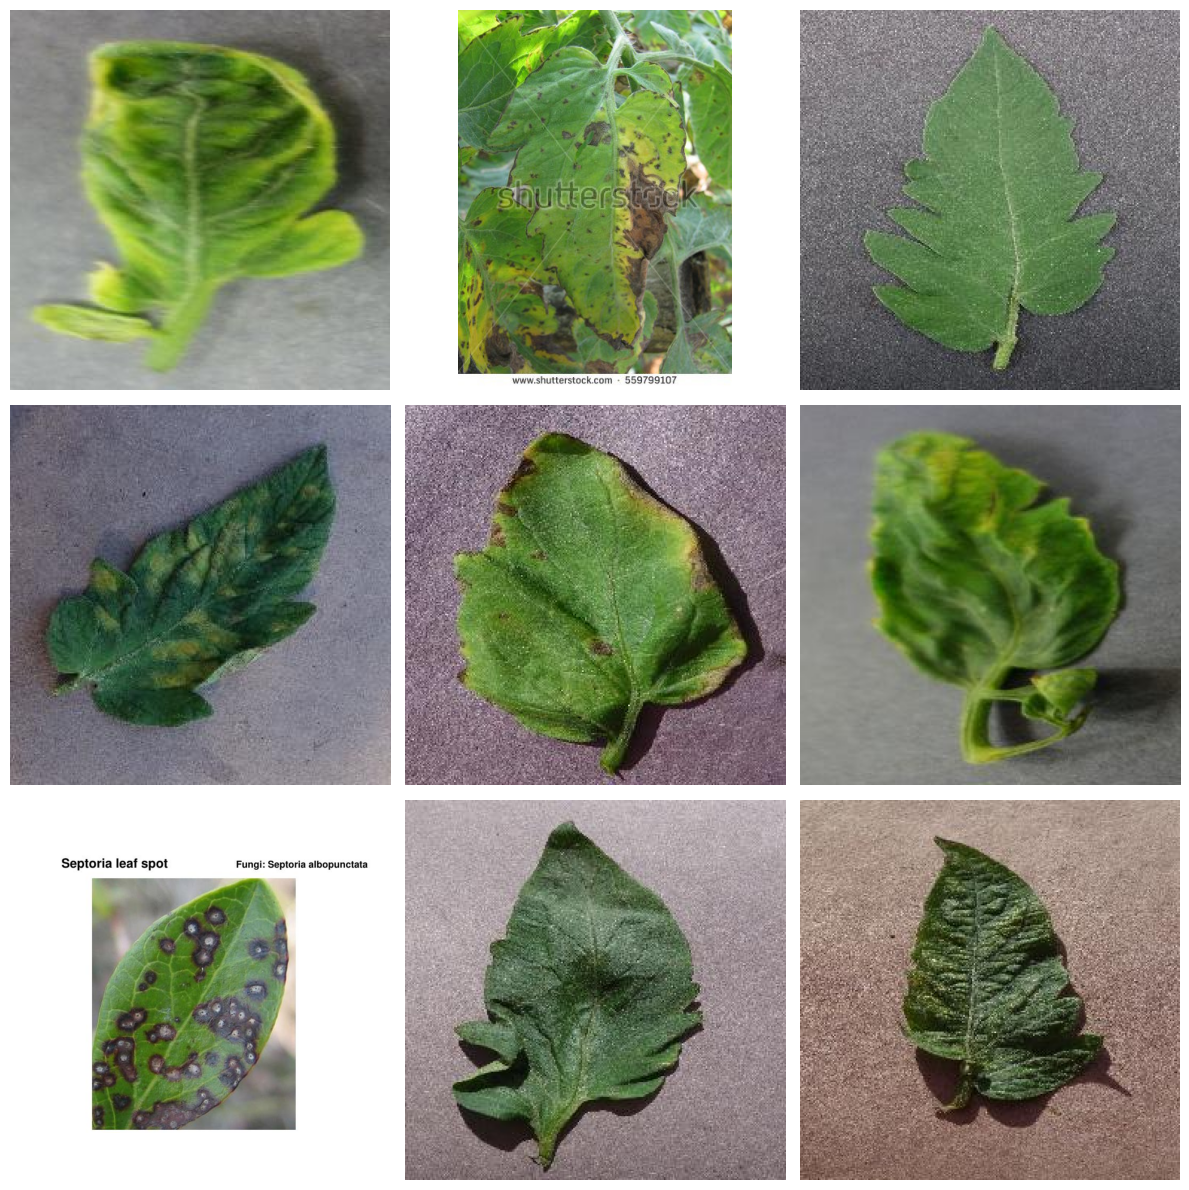

In [9]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

IMG_DIR = "/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/images/train"

images = []

for root, dirs, files in os.walk(IMG_DIR):
    for f in files:
        if f.endswith((".jpg",".jpeg",".png")):
            images.append(os.path.join(root,f))

sample = random.sample(images, 9)

plt.figure(figsize=(12,12))

for i,img_path in enumerate(sample):
    img = mpimg.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import os
from collections import Counter

label_dir = "/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/labels/train"

counts = Counter()

for file in os.listdir(label_dir):
    if file.endswith(".txt"):
        with open(os.path.join(label_dir, file), "r") as f:
            lines = f.readlines()

            for line in lines:
                cls = int(line.split()[0])
                counts[cls] += 1

print(counts)

Counter({9: 1837, 6: 1764, 0: 1729, 3: 1702, 2: 1604, 7: 1344, 8: 1125, 4: 1011, 1: 990, 5: 518})


In [7]:
names = [
'Tomato__BacterialSpot',
'Tomato__EarlyBlight',
'Tomato__Healthy',
'Tomato__LateBlight',
'Tomato__LeafMold',
'Tomato__MosaicVirus',
'Tomato__SeptoriaLeafSpot',
'Tomato__SpiderMites',
'Tomato__TargetSpot',
'Tomato__YellowLeafCurlVirus'
]

for k,v in sorted(counts.items()):
    print(names[k], ":", v)

Tomato__BacterialSpot : 1729
Tomato__EarlyBlight : 990
Tomato__Healthy : 1604
Tomato__LateBlight : 1702
Tomato__LeafMold : 1011
Tomato__MosaicVirus : 518
Tomato__SeptoriaLeafSpot : 1764
Tomato__SpiderMites : 1344
Tomato__TargetSpot : 1125
Tomato__YellowLeafCurlVirus : 1837


In [8]:
import os

label_dir = "/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/labels/train"

for file in os.listdir(label_dir)[:5]:
    with open(os.path.join(label_dir, file)) as f:
        print(file)
        print(f.read())
        print("-"*50)

pv_TMHE_image (578).txt
2 0.453125 0.513672 0.882812 0.964844
--------------------------------------------------
pv_TMLB_image (772).txt
3 0.521484 0.498047 0.871094 0.988281
--------------------------------------------------
pv_TMLB_image (525).txt
3 0.529297 0.484375 0.832031 0.960938
--------------------------------------------------
pv_TMHE_image (137).txt
2 0.542969 0.480469 0.625 0.90625
--------------------------------------------------
pv_TMYC_image (229).txt
9 0.482422 0.5 0.871094 0.960938
--------------------------------------------------
